# DLS FR — Cross-Entropy dual-dataset remaster (Fall 2025 + Spring 2026)

This notebook fixes the fundamental validation-contract problem in the previous Spring-2026 CE baseline.

## Canonical routing

```text
Fall 2025 train
    -> CE optimization

Fall 2025 val
    -> same-identity classification validation
    -> checkpoint selection
    -> DLS accuracy threshold check (> 0.70)

Fall 2025 test
    -> independent same-identity control
    -> evaluated only after checkpoint selection

Spring 2026 final query + distractors
    -> remove every identity appearing anywhere in Fall 2025
    -> frozen identity-disjoint final evaluation
    -> Rank-1 / ROC AUC / EER / TPR@FPR
```

**Important:** Spring final-test metrics are not computed during training and are not used for checkpoint or hyperparameter selection.

Recognition preprocessing remains:
`PIL/RGB -> Resize(112,112) -> ToTensor -> Normalize(0.5,0.5,0.5)`.

## Cell 1 — Imports

In [1]:
import os, json, time, math, random, platform
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

print("[sanity] python:", platform.python_version())
print("[sanity] torch:", torch.__version__)
print("[sanity] torchvision:", torchvision.__version__)
print("[sanity] imports OK")

[sanity] python: 3.13.5
[sanity] torch: 2.9.1
[sanity] torchvision: 0.24.1
[sanity] imports OK


## Cell 2 — Device

In [2]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()
PIN_MEMORY = device.type == "cuda"
print("[sanity] device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False

[sanity] device: mps


## Cell 3 — Config

In [3]:
# ============================================================
# EDIT THESE ROOTS ONLY IF THE PROJECT / DATASETS MOVE
# ============================================================

# Fall 2025: dense same-identity train/val/test structure.
OLD_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj")
FALL_ROOT = OLD_ROOT / "celeba_wild_aligned_112_splits_20"

# Spring 2026: identity-disjoint infrastructure and authoritative manifest.
THE_ROOT = Path("/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject")
SPRING_ROOT = THE_ROOT / "Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1"
SPRING_DATA_ROOT = SPRING_ROOT / "celeba_21k_aligned"
SPRING_MANIFEST = SPRING_ROOT / "final_21k_selection.csv"

SEED = 42
IMG_SIZE = 112
BATCH_SIZE = 128
NUM_WORKERS = 0

EPOCHS = 21
REFERENCE_EPOCH = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4

BACKBONE = "resnet18"
PRETRAINED = True

USE_RANDOM_HFLIP = True
USE_COLORJITTER = False

BEST_CHECKPOINT_METRIC = "sameid_val_acc"
DLS_ACCURACY_THRESHOLD = 0.70

RUN_NAME = f"ce_resnet18_dual_Fall2025_Spring2026_ep{EPOCHS}_v1"
RUN_DIR = SPRING_ROOT / "_recognition_runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Startup sanity
# ============================================================
assert FALL_ROOT.exists(), f"FALL_ROOT not found: {FALL_ROOT}"
for split in ["train", "val", "test"]:
    p = FALL_ROOT / split / "images"
    assert p.exists(), f"Missing Fall dataset directory: {p}"

assert SPRING_DATA_ROOT.exists(), f"SPRING_DATA_ROOT not found: {SPRING_DATA_ROOT}"
assert SPRING_MANIFEST.exists(), f"SPRING_MANIFEST not found: {SPRING_MANIFEST}"

for p in [
    SPRING_DATA_ROOT / "train",
    SPRING_DATA_ROOT / "validation",
    SPRING_DATA_ROOT / "test" / "query",
    SPRING_DATA_ROOT / "test" / "distractors",
]:
    assert p.exists(), f"Missing Spring dataset directory: {p}"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("[sanity] FALL_ROOT:", FALL_ROOT)
print("[sanity] SPRING_ROOT:", SPRING_ROOT)
print("[sanity] RUN_DIR:", RUN_DIR)
print("[sanity] backbone:", BACKBONE, "| pretrained:", PRETRAINED)
print("[sanity] checkpoint metric:", BEST_CHECKPOINT_METRIC)
print("[sanity] DLS accuracy threshold: >", DLS_ACCURACY_THRESHOLD)

[sanity] FALL_ROOT: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2025.1.1осень/10_PROj/celeba_wild_aligned_112_splits_20
[sanity] SPRING_ROOT: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1
[sanity] RUN_DIR: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/ce_resnet18_dual_Fall2025_Spring2026_ep21_v1
[sanity] backbone: resnet18 | pretrained: True
[sanity] checkpoint metric: sameid_val_acc
[sanity] DLS accuracy threshold: > 0.7


## Cell 4 — Index Fall 2025 same-identity train / val / test

In [4]:
legacy_train_index = ImageFolder(FALL_ROOT / "train" / "images")
legacy_val_index   = ImageFolder(FALL_ROOT / "val" / "images")
legacy_test_index  = ImageFolder(FALL_ROOT / "test" / "images")

assert legacy_train_index.classes == legacy_val_index.classes == legacy_test_index.classes, (
    "Fall train/val/test must contain exactly the same identity folders."
)
assert legacy_train_index.class_to_idx == legacy_val_index.class_to_idx == legacy_test_index.class_to_idx

identity_to_class = dict(legacy_train_index.class_to_idx)
num_classes = len(identity_to_class)


def imagefolder_to_table(ds: ImageFolder, split_name: str) -> pd.DataFrame:
    idx_to_class = {idx: name for name, idx in ds.class_to_idx.items()}
    rows = []
    for path_str, class_idx in ds.samples:
        path = Path(path_str)
        rows.append({
            "filename": path.name,
            "identity_id": str(idx_to_class[int(class_idx)]),
            "class_idx": int(class_idx),
            "subset": split_name,
            "resolved_path": str(path.resolve()),
        })
    return pd.DataFrame(rows)

train_df = imagefolder_to_table(legacy_train_index, "train")
sameid_val_df = imagefolder_to_table(legacy_val_index, "val")
sameid_test_df = imagefolder_to_table(legacy_test_index, "test")

assert len(train_df) > 0 and len(sameid_val_df) > 0 and len(sameid_test_df) > 0
assert train_df["class_idx"].nunique() == num_classes
assert sameid_val_df["class_idx"].nunique() == num_classes
assert sameid_test_df["class_idx"].nunique() == num_classes

fall_train_ids = set(train_df["identity_id"])
fall_val_ids = set(sameid_val_df["identity_id"])
fall_test_ids = set(sameid_test_df["identity_id"])
fall_ids = fall_train_ids | fall_val_ids | fall_test_ids

assert fall_train_ids == fall_val_ids == fall_test_ids

# Files are independent even though identities are shared.
assert set(train_df["resolved_path"]).isdisjoint(set(sameid_val_df["resolved_path"]))
assert set(train_df["resolved_path"]).isdisjoint(set(sameid_test_df["resolved_path"]))
assert set(sameid_val_df["resolved_path"]).isdisjoint(set(sameid_test_df["resolved_path"]))

mapping_df = pd.DataFrame({
    "identity_id": legacy_train_index.classes,
    "class_idx": [identity_to_class[x] for x in legacy_train_index.classes],
})
mapping_path = RUN_DIR / "identity_to_class.csv"
mapping_df.to_csv(mapping_path, index=False)

fall_manifest = pd.concat([train_df, sameid_val_df, sameid_test_df], ignore_index=True)
fall_manifest_path = RUN_DIR / "fall2025_dataset_manifest.csv"
fall_manifest.to_csv(fall_manifest_path, index=False)


def describe_counts(table, name):
    counts = table.groupby("identity_id").size()
    print(
        f"[sanity] {name}: images={len(table)} ids={counts.size} | "
        f"images/id min={counts.min()} median={counts.median():.1f} "
        f"mean={counts.mean():.2f} max={counts.max()}"
    )

for table, name in [
    (train_df, "Fall train"),
    (sameid_val_df, "Fall val"),
    (sameid_test_df, "Fall test"),
]:
    describe_counts(table, name)

print("[sanity] classifier classes:", num_classes)
print("[OK] Fall same-identity contract passed")

[sanity] Fall train: images=13271 ids=666 | images/id min=16 median=20.0 mean=19.93 max=20
[sanity] Fall val: images=1329 ids=666 | images/id min=1 median=2.0 mean=2.00 max=2
[sanity] Fall test: images=1330 ids=666 | images/id min=1 median=2.0 mean=2.00 max=2
[sanity] classifier classes: 666
[OK] Fall same-identity contract passed


## Cell 5 — Load Spring 2026 manifest and build frozen Spring-only final test

In [5]:
spring_df = pd.read_csv(
    SPRING_MANIFEST,
    dtype={
        "filename": str,
        "identity_id": str,
        "final_subset": str,
        "aligned_path": str,
    },
)

required_cols = {"filename", "identity_id", "final_subset", "aligned_path"}
missing = required_cols - set(spring_df.columns)
assert not missing, f"Missing required Spring manifest columns: {sorted(missing)}"


def canonical_subset(x: str) -> str:
    x = str(x).strip().lower().replace("-", "_").replace("/", "_")
    aliases = {
        "train": "train",
        "validation": "validation",
        "val": "validation",
        "test_query": "test_query",
        "query": "test_query",
        "test_distractors": "test_distractor",
        "test_distractor": "test_distractor",
        "distractors": "test_distractor",
        "distractor": "test_distractor",
    }
    if x not in aliases:
        raise ValueError(f"Unknown final_subset value: {x!r}")
    return aliases[x]

spring_df["subset"] = spring_df["final_subset"].map(canonical_subset)


def canonical_spring_path(subset: str, filename: str) -> Path:
    if subset == "train":
        return SPRING_DATA_ROOT / "train" / filename
    if subset == "validation":
        return SPRING_DATA_ROOT / "validation" / filename
    if subset == "test_query":
        return SPRING_DATA_ROOT / "test" / "query" / filename
    if subset == "test_distractor":
        return SPRING_DATA_ROOT / "test" / "distractors" / filename
    raise ValueError(subset)


def resolve_spring_path(row) -> Path:
    # aligned_path can be obsolete after moving the project.
    manifest_path = Path(str(row["aligned_path"])).expanduser()
    if manifest_path.exists():
        return manifest_path
    return canonical_spring_path(row["subset"], row["filename"])

spring_df["resolved_path"] = spring_df.apply(resolve_spring_path, axis=1)

# Frozen final subsets only. Spring train/validation are not used by this CE remaster.
spring_final = spring_df[spring_df["subset"].isin(["test_query", "test_distractor"])].copy()

# Mandatory cross-dataset filtering: remove every identity present anywhere in Fall.
spring_only_final = spring_final[~spring_final["identity_id"].isin(fall_ids)].copy().reset_index(drop=True)
spring_query_df = spring_only_final[spring_only_final["subset"] == "test_query"].copy().reset_index(drop=True)
spring_distractor_df = spring_only_final[spring_only_final["subset"] == "test_distractor"].copy().reset_index(drop=True)

query_ids = set(spring_query_df["identity_id"])
distractor_ids = set(spring_distractor_df["identity_id"])

assert fall_ids.isdisjoint(query_ids)
assert fall_ids.isdisjoint(distractor_ids)
assert query_ids.isdisjoint(distractor_ids)

missing_paths = spring_only_final.loc[
    ~spring_only_final["resolved_path"].map(Path.exists),
    ["subset", "filename", "identity_id", "resolved_path"],
]
assert len(missing_paths) == 0, (
    f"{len(missing_paths)} Spring final image paths do not exist. "
    f"First examples:\n{missing_paths.head(10).to_string(index=False)}"
)

query_counts = spring_query_df.groupby("identity_id").size()
distractor_counts = spring_distractor_df.groupby("identity_id").size()
assert (query_counts == 4).all(), "Every retained Spring query identity must still have 4 images"
assert (distractor_counts == 1).all(), "Every retained Spring distractor identity must have 1 image"

spring_only_manifest_path = RUN_DIR / "spring2026_frozen_final_spring_only_manifest.csv"
spring_only_final.to_csv(spring_only_manifest_path, index=False)

print("[sanity] Fall identities:", len(fall_ids))
print("[sanity] Spring final identities before filtering:", spring_final["identity_id"].nunique())
print("[sanity] Spring-only query: images=", len(spring_query_df), "ids=", len(query_ids))
print("[sanity] Spring-only distractors: images=", len(spring_distractor_df), "ids=", len(distractor_ids))
print("[OK] cross-dataset identity-disjoint assertions passed")
print("[OK] saved:", spring_only_manifest_path)

[sanity] Fall identities: 666
[sanity] Spring final identities before filtering: 2250
[sanity] Spring-only query: images= 940 ids= 235
[sanity] Spring-only distractors: images= 1872 ids= 1872
[OK] cross-dataset identity-disjoint assertions passed
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/ce_resnet18_dual_Fall2025_Spring2026_ep21_v1/spring2026_frozen_final_spring_only_manifest.csv


## Cell 6 — Recognition transforms

In [6]:
train_tfms = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
]
if USE_RANDOM_HFLIP:
    train_tfms.insert(1, transforms.RandomHorizontalFlip(p=0.5))
if USE_COLORJITTER:
    train_tfms.insert(
        1,
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    )

train_tfm = transforms.Compose(train_tfms)
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("[sanity] transforms ready")

[sanity] transforms ready


## Cell 7 — Dataset wrappers

In [7]:
class FaceTableDataset(Dataset):
    def __init__(self, table: pd.DataFrame, transform, classification: bool):
        self.table = table.reset_index(drop=True).copy()
        self.transform = transform
        self.classification = bool(classification)

        required = {"resolved_path", "identity_id"}
        if self.classification:
            required.add("class_idx")
        missing = required - set(self.table.columns)
        if missing:
            raise ValueError(f"Dataset table missing columns: {sorted(missing)}")

    def __len__(self):
        return len(self.table)

    def __getitem__(self, idx):
        row = self.table.iloc[idx]
        with Image.open(Path(row["resolved_path"])) as im:
            image = im.convert("RGB")
        image = self.transform(image)

        if self.classification:
            return image, int(row["class_idx"])
        return image, str(row["identity_id"])


ds_train = FaceTableDataset(train_df, train_tfm, classification=True)
ds_val_sameid = FaceTableDataset(sameid_val_df, eval_tfm, classification=True)
ds_test_sameid = FaceTableDataset(sameid_test_df, eval_tfm, classification=True)
ds_spring_final = FaceTableDataset(spring_only_final, eval_tfm, classification=False)

print("[sanity] dataset sizes:", {
    "fall_train": len(ds_train),
    "fall_val_sameid": len(ds_val_sameid),
    "fall_test_sameid": len(ds_test_sameid),
    "spring_final_disjoint": len(ds_spring_final),
})

x0, y0 = ds_train[0]
assert x0.shape == (3, IMG_SIZE, IMG_SIZE)
assert 0 <= y0 < num_classes

[sanity] dataset sizes: {'fall_train': 13271, 'fall_val_sameid': 1329, 'fall_test_sameid': 1330, 'spring_final_disjoint': 2812}


## Cell 8 — DataLoaders

In [8]:
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

dl_train = DataLoader(ds_train, shuffle=True, **loader_kwargs)
dl_val_sameid = DataLoader(ds_val_sameid, shuffle=False, **loader_kwargs)
dl_test_sameid = DataLoader(ds_test_sameid, shuffle=False, **loader_kwargs)
dl_spring_final = DataLoader(ds_spring_final, shuffle=False, **loader_kwargs)

xb, yb = next(iter(dl_train))
xv, yv = next(iter(dl_val_sameid))
print("[sanity] train batch:", xb.shape, yb.shape)
print("[sanity] val batch:", xv.shape, yv.shape)
assert yb.max().item() < num_classes
assert yv.max().item() < num_classes

[sanity] train batch: torch.Size([128, 3, 112, 112]) torch.Size([128])
[sanity] val batch: torch.Size([128, 3, 112, 112]) torch.Size([128])


## Cell 9 — ResNet backbone + CE classifier

In [9]:
class CEResNet(nn.Module):
    def __init__(self, backbone: str, num_classes: int, pretrained: bool):
        super().__init__()
        backbone = backbone.lower()

        if backbone == "resnet18":
            weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet18(weights=weights)
        elif backbone == "resnet34":
            weights = torchvision.models.ResNet34_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet34(weights=weights)
        elif backbone == "resnet50":
            weights = torchvision.models.ResNet50_Weights.DEFAULT if pretrained else None
            net = torchvision.models.resnet50(weights=weights)
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        self.backbone_name = backbone
        self.embedding_dim = int(net.fc.in_features)
        net.fc = nn.Identity()
        self.backbone = net
        self.classifier = nn.Linear(self.embedding_dim, num_classes)

    def forward_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))

model = CEResNet(BACKBONE, num_classes, PRETRAINED).to(device)

n_params = sum(p.numel() for p in model.parameters())
print("[sanity] embedding_dim:", model.embedding_dim)
print("[sanity] params total:", n_params)

model.eval()
with torch.no_grad():
    logits = model(xb.to(device)[:4])
    emb = model.forward_features(xb.to(device)[:4])
assert logits.shape == (4, num_classes)
assert emb.shape == (4, model.embedding_dim)

[sanity] embedding_dim: 512
[sanity] params total: 11518170


## Cell 10 — Loss / optimizer / scheduler

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print("[sanity] optimizer/scheduler OK")

[sanity] optimizer/scheduler OK


## Cell 11 — Training + honest Fall same-identity validation

Checkpoint selection uses **Fall val classification accuracy only**. Spring final-test metrics are deliberately absent from this loop.

In [11]:
def train_epoch(model, loader, device):
    model.train()
    loss_sum = 0.0
    correct = 0.0
    n = 0

    for step, (xb, yb) in enumerate(loader, start=1):
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        correct += (logits.argmax(dim=1) == yb).float().sum().item()
        n += bs

        if step % 50 == 0:
            print(f"[train] step={step:04d} seen={n:05d} batch_loss={loss.item():.4f}")

    return {"loss": loss_sum / n, "acc": correct / n}


@torch.no_grad()
def evaluate_classification(model, loader, device):
    model.eval()
    loss_sum = 0.0
    correct = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)
        logits = model(xb)
        loss = criterion(logits, yb)

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        correct += (logits.argmax(dim=1) == yb).float().sum().item()
        n += bs

    return {"loss": loss_sum / n, "acc": correct / n}


history = []
best = {"sameid_val_acc": -1.0, "sameid_val_loss": float("inf"), "epoch": -1}
best_path = RUN_DIR / "best.pt"
latest_path = RUN_DIR / "latest.pt"
reference_path = RUN_DIR / f"epoch_{REFERENCE_EPOCH:03d}_reference.pt"
history_path = RUN_DIR / "history.csv"
history_json_path = RUN_DIR / "history.json"

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_t0 = time.time()

    tr = train_epoch(model, dl_train, device)
    sv = evaluate_classification(model, dl_val_sameid, device)

    scheduler.step()

    row = {
        "epoch": int(epoch),
        "train_loss": float(tr["loss"]),
        "train_acc": float(tr["acc"]),
        "sameid_val_loss": float(sv["loss"]),
        "sameid_val_acc": float(sv["acc"]),
        "acc_generalization_gap": float(tr["acc"] - sv["acc"]),
        "loss_generalization_gap": float(sv["loss"] - tr["loss"]),
        "dls_threshold_passed": bool(sv["acc"] > DLS_ACCURACY_THRESHOLD),
        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(time.time() - epoch_t0),
        "time_min_total": float((time.time() - t0) / 60.0),
    }
    history.append(row)

    payload = {
        "model_state": model.state_dict(),
        "backbone": BACKBONE,
        "embedding_dim": int(model.embedding_dim),
        "num_classes": int(num_classes),
        "epoch": int(epoch),
        "sameid_validation_metrics": {
            "ce_loss": float(sv["loss"]),
            "accuracy": float(sv["acc"]),
            "dls_threshold": float(DLS_ACCURACY_THRESHOLD),
            "dls_threshold_passed": bool(sv["acc"] > DLS_ACCURACY_THRESHOLD),
        },
        "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
        "config": {
            "IMG_SIZE": IMG_SIZE,
            "BATCH_SIZE": BATCH_SIZE,
            "EPOCHS": EPOCHS,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "PRETRAINED": PRETRAINED,
            "SEED": SEED,
            "USE_RANDOM_HFLIP": USE_RANDOM_HFLIP,
            "USE_COLORJITTER": USE_COLORJITTER,
        },
    }

    torch.save(payload, latest_path)
    if epoch == REFERENCE_EPOCH:
        torch.save(payload, reference_path)

    # Primary criterion: maximum same-ID validation accuracy.
    # Tie-breaker: lower same-ID validation CE loss.
    better = (
        sv["acc"] > best["sameid_val_acc"]
        or (
            np.isclose(sv["acc"], best["sameid_val_acc"])
            and sv["loss"] < best["sameid_val_loss"]
        )
    )
    if better:
        best = {
            "sameid_val_acc": float(sv["acc"]),
            "sameid_val_loss": float(sv["loss"]),
            "epoch": int(epoch),
        }
        torch.save(payload, best_path)

    # Persist every completed epoch.
    pd.DataFrame(history).to_csv(history_path, index=False)
    history_json_path.write_text(json.dumps(history, indent=2))

    print(
        f"[epoch {epoch:02d}] "
        f"TRAIN loss={tr['loss']:.4f} acc={tr['acc']:.4f} | "
        f"FALL VAL loss={sv['loss']:.4f} acc={sv['acc']:.4f} | "
        f"DLS>0.70={'PASS' if sv['acc'] > DLS_ACCURACY_THRESHOLD else 'FAIL'} | "
        f"lr={row['lr']:.2e} time={row['epoch_time_sec']:.1f}s"
    )

print("[OK] history:", history_path)
print("[OK] best:", best)
print("[OK] best checkpoint:", best_path)

[train] step=0050 seen=06400 batch_loss=5.6603
[train] step=0100 seen=12800 batch_loss=4.5546
[epoch 01] TRAIN loss=5.6948 acc=0.0449 | FALL VAL loss=4.6890 acc=0.0767 | DLS>0.70=FAIL | lr=9.94e-04 time=39.8s
[train] step=0050 seen=06400 batch_loss=3.4375
[train] step=0100 seen=12800 batch_loss=3.3965
[epoch 02] TRAIN loss=3.5613 acc=0.2340 | FALL VAL loss=3.2065 acc=0.3017 | DLS>0.70=FAIL | lr=9.78e-04 time=35.1s
[train] step=0050 seen=06400 batch_loss=2.2008
[train] step=0100 seen=12800 batch_loss=2.1178
[epoch 03] TRAIN loss=2.2331 acc=0.4853 | FALL VAL loss=2.6276 acc=0.4116 | DLS>0.70=FAIL | lr=9.50e-04 time=34.7s
[train] step=0050 seen=06400 batch_loss=1.2540
[train] step=0100 seen=12800 batch_loss=1.5769
[epoch 04] TRAIN loss=1.3923 acc=0.6767 | FALL VAL loss=2.5075 acc=0.4199 | DLS>0.70=FAIL | lr=9.13e-04 time=35.5s
[train] step=0050 seen=06400 batch_loss=0.7625
[train] step=0100 seen=12800 batch_loss=0.7672
[epoch 05] TRAIN loss=0.8311 acc=0.8091 | FALL VAL loss=2.3918 acc=0.4

## Cell 12 — Reload best checkpoint; Fall val + untouched Fall test control

Fall test is evaluated here for the first time. It is same-ID / seen-ID evidence, not unseen-identity evidence.

In [12]:
assert best_path.exists(), f"Missing checkpoint: {best_path}"
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"])

best_epoch = int(ckpt["epoch"])
best_val = evaluate_classification(model, dl_val_sameid, device)
fall_test_metrics = evaluate_classification(model, dl_test_sameid, device)

assert abs(best_val["acc"] - float(ckpt["sameid_validation_metrics"]["accuracy"])) < 1e-12

sameid_metrics_df = pd.DataFrame([{
    "selected_epoch": best_epoch,
    "fall_val_ce_loss": float(best_val["loss"]),
    "fall_val_accuracy": float(best_val["acc"]),
    "dls_accuracy_threshold": float(DLS_ACCURACY_THRESHOLD),
    "dls_threshold_passed": bool(best_val["acc"] > DLS_ACCURACY_THRESHOLD),
    "fall_test_ce_loss": float(fall_test_metrics["loss"]),
    "fall_test_accuracy": float(fall_test_metrics["acc"]),
}])
sameid_metrics_path = RUN_DIR / "fall_sameid_best_checkpoint_metrics.csv"
sameid_metrics_df.to_csv(sameid_metrics_path, index=False)

print("[BEST] epoch =", best_epoch)
print("[BEST] Fall val accuracy = %.4f" % best_val["acc"])
print("[DLS] required > %.2f : %s" % (
    DLS_ACCURACY_THRESHOLD,
    "PASS" if best_val["acc"] > DLS_ACCURACY_THRESHOLD else "FAIL",
))
print("[CONTROL] Fall test accuracy = %.4f" % fall_test_metrics["acc"])
print("[OK] saved:", sameid_metrics_path)

[BEST] epoch = 20
[BEST] Fall val accuracy = 0.7705
[DLS] required > 0.70 : PASS
[CONTROL] Fall test accuracy = 0.7707
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/ce_resnet18_dual_Fall2025_Spring2026_ep21_v1/fall_sameid_best_checkpoint_metrics.csv


## Cell 13 — Frozen Spring-only identity-disjoint final evaluation

This is the only place where Spring final query+distractor identities are evaluated. The classifier head is not used; cosine similarity is computed from L2-normalized penultimate ResNet embeddings.

Rank-1 protocol: each retained Spring query image is a probe; its gallery contains every other retained query image plus all distractors. The probe itself is excluded. A hit requires the nearest gallery embedding to have the same identity.

In [13]:
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    all_embeddings = []
    all_identity_ids = []

    for xb, identity_ids in loader:
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        emb = model.forward_features(xb)
        emb = F.normalize(emb, p=2, dim=1)
        all_embeddings.append(emb.cpu())
        all_identity_ids.extend([str(x) for x in identity_ids])

    return torch.cat(all_embeddings, dim=0), np.asarray(all_identity_ids, dtype=str)


spring_embeddings, spring_identity_ids = extract_embeddings(model, dl_spring_final, device)

spring_subsets = spring_only_final["subset"].astype(str).to_numpy()
query_mask = spring_subsets == "test_query"
query_indices = np.where(query_mask)[0]

# ------------------------------------------------------------
# Query-probe Rank-1 against all other final-test images.
# ------------------------------------------------------------
sim = spring_embeddings @ spring_embeddings.T
rank_sim = sim.clone()
rank_sim.fill_diagonal_(-float("inf"))

nn_idx = torch.argmax(rank_sim[query_indices], dim=1).cpu().numpy()
pred_ids = spring_identity_ids[nn_idx]
true_query_ids = spring_identity_ids[query_indices]
spring_rank1 = float(np.mean(pred_ids == true_query_ids))

# ------------------------------------------------------------
# Verification pairs: all unordered pairs in the frozen final pool.
# Genuine pairs exist only between images of the retained query IDs.
# ------------------------------------------------------------
n = len(spring_identity_ids)
upper_i, upper_j = np.triu_indices(n, k=1)
scores = sim[upper_i, upper_j].cpu().numpy()
same_identity = spring_identity_ids[upper_i] == spring_identity_ids[upper_j]

genuine_scores = scores[same_identity]
impostor_scores = scores[~same_identity]

assert len(genuine_scores) > 0
assert len(impostor_scores) > 0

from sklearn.metrics import roc_curve, roc_auc_score

labels = same_identity.astype(np.int32)
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = float(roc_auc_score(labels, scores))

fnr = 1.0 - tpr
eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2.0)
eer_threshold = float(thresholds[eer_idx])

rows = []
for target_fpr in [0.5, 0.2, 0.1, 5e-2, 1e-2, 1e-3, 1e-4]:
    valid = np.where(fpr <= target_fpr)[0]
    if len(valid) == 0:
        rows.append({
            "target_FPR": target_fpr,
            "actual_FPR": np.nan,
            "TPR": np.nan,
            "cosine_threshold": np.nan,
        })
    else:
        idx = valid[-1]
        rows.append({
            "target_FPR": target_fpr,
            "actual_FPR": float(fpr[idx]),
            "TPR": float(tpr[idx]),
            "cosine_threshold": float(thresholds[idx]),
        })

tpr_df = pd.DataFrame(rows)
tpr_path = RUN_DIR / "spring_only_tpr_at_fpr.csv"
tpr_df.to_csv(tpr_path, index=False)

spring_summary_df = pd.DataFrame([{
    "selected_epoch": best_epoch,
    "query_images": int(query_mask.sum()),
    "query_identities": int(len(query_ids)),
    "distractor_images": int((~query_mask).sum()),
    "distractor_identities": int(len(distractor_ids)),
    "rank1_query_probe": spring_rank1,
    "roc_auc": roc_auc,
    "eer": eer,
    "eer_threshold": eer_threshold,
    "genuine_pairs": int(len(genuine_scores)),
    "impostor_pairs": int(len(impostor_scores)),
    "genuine_cos_mean": float(genuine_scores.mean()),
    "genuine_cos_std": float(genuine_scores.std()),
    "impostor_cos_mean": float(impostor_scores.mean()),
    "impostor_cos_std": float(impostor_scores.std()),
    "cosine_mean_gap": float(genuine_scores.mean() - impostor_scores.mean()),
}])
spring_summary_path = RUN_DIR / "spring_only_final_metrics.csv"
spring_summary_df.to_csv(spring_summary_path, index=False)

spring_embeddings_path = RUN_DIR / "spring_only_final_embeddings.npz"
np.savez_compressed(
    spring_embeddings_path,
    embeddings=spring_embeddings.numpy(),
    identity_id=spring_identity_ids,
    subset=spring_subsets,
    filename=spring_only_final["filename"].astype(str).to_numpy(),
)

print("=== Spring-only frozen final test ===")
print("Rank-1 (query probes) = %.4f" % spring_rank1)
print("ROC AUC               = %.4f" % roc_auc)
print("EER                   = %.4f" % eer)
print("Genuine cosine mean   = %.4f" % genuine_scores.mean())
print("Impostor cosine mean  = %.4f" % impostor_scores.mean())
print("\nTPR@FPR:")
print(tpr_df.to_string(index=False))
print("[OK] saved:", spring_summary_path)
print("[OK] saved:", tpr_path)
print("[OK] saved:", spring_embeddings_path)

=== Spring-only frozen final test ===
Rank-1 (query probes) = 0.4191
ROC AUC               = 0.9528
EER                   = 0.1163
Genuine cosine mean   = 0.6714
Impostor cosine mean  = 0.4093

TPR@FPR:
 target_FPR  actual_FPR      TPR  cosine_threshold
     0.5000    0.499999 0.984397          0.399081
     0.2000    0.200000 0.929078          0.475145
     0.1000    0.100000 0.867376          0.522199
     0.0500    0.049999 0.797872          0.564371
     0.0100    0.010000 0.593617          0.648761
     0.0010    0.000998 0.300709          0.742285
     0.0001    0.000100 0.127660          0.812606
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/_recognition_runs/ce_resnet18_dual_Fall2025_Spring2026_ep21_v1/spring_only_final_metrics.csv
[OK] saved: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/ou

## Cell 14 — Diagnostic plots

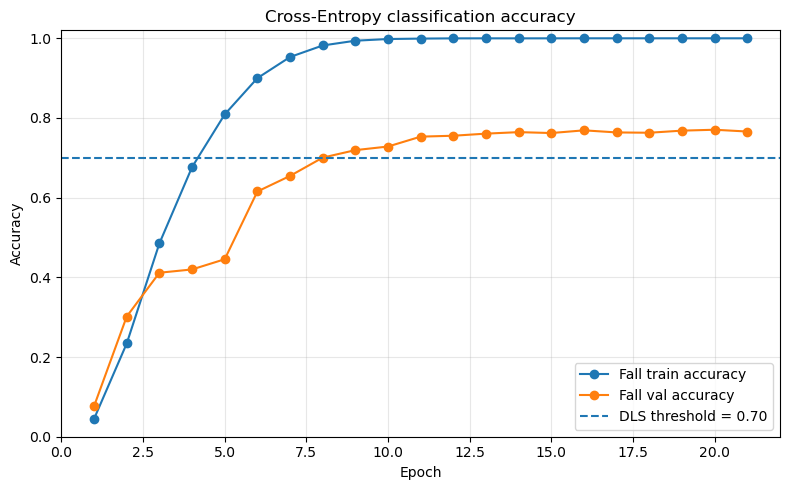

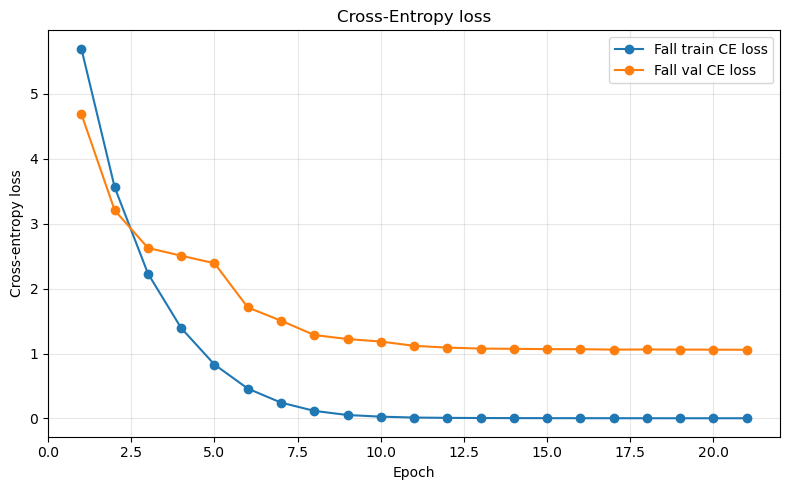

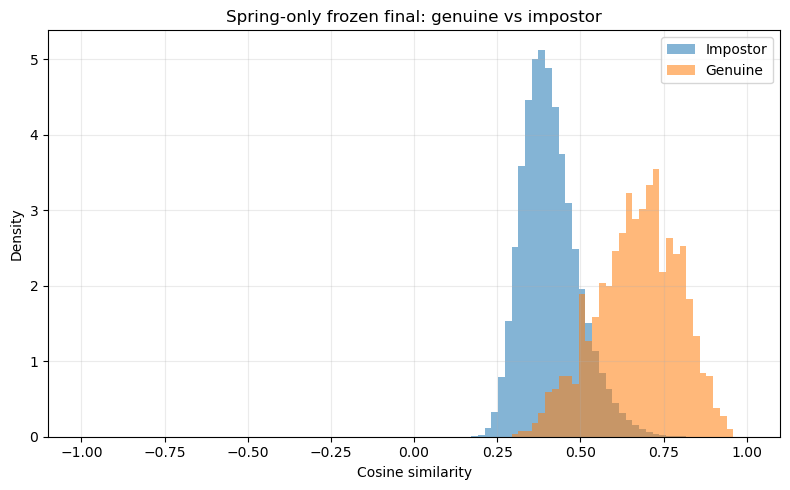

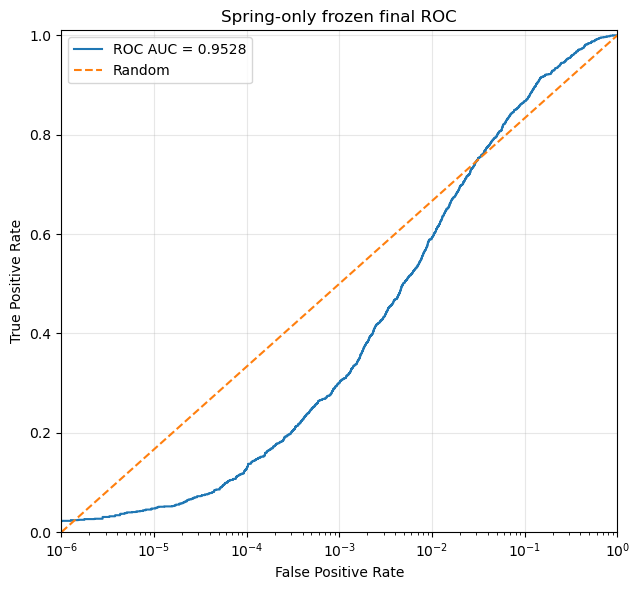

In [14]:
import matplotlib.pyplot as plt

hist = pd.read_csv(RUN_DIR / "history.csv")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Fall train accuracy")
plt.plot(hist["epoch"], hist["sameid_val_acc"], marker="o", label="Fall val accuracy")
plt.axhline(DLS_ACCURACY_THRESHOLD, linestyle="--", label="DLS threshold = 0.70")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.02)
plt.title("Cross-Entropy classification accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Fall train CE loss")
plt.plot(hist["epoch"], hist["sameid_val_loss"], marker="o", label="Fall val CE loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Cross-Entropy loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
bins = np.linspace(-1.0, 1.0, 100)
plt.hist(impostor_scores, bins=bins, density=True, alpha=0.55, label="Impostor")
plt.hist(genuine_scores, bins=bins, density=True, alpha=0.55, label="Genuine")
plt.xlabel("Cosine similarity")
plt.ylabel("Density")
plt.title("Spring-only frozen final: genuine vs impostor")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([1e-6, 1.0], [1e-6, 1.0], linestyle="--", label="Random")
plt.xscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(0.0, 1.01)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spring-only frozen final ROC")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Cell 15 — Run artifacts / summary

In [15]:
config = {
    "FALL_ROOT": str(FALL_ROOT),
    "SPRING_ROOT": str(SPRING_ROOT),
    "SPRING_MANIFEST": str(SPRING_MANIFEST),
    "RUN_DIR": str(RUN_DIR),
    "seed": int(SEED),
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "num_workers": int(NUM_WORKERS),
    "epochs": int(EPOCHS),
    "reference_epoch": int(REFERENCE_EPOCH),
    "lr": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "backbone": BACKBONE,
    "pretrained": bool(PRETRAINED),
    "embedding_dim": int(model.embedding_dim),
    "num_train_classes": int(num_classes),
    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "random_horizontal_flip": bool(USE_RANDOM_HFLIP),
    "color_jitter": bool(USE_COLORJITTER),
    "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
    "dls_accuracy_threshold": float(DLS_ACCURACY_THRESHOLD),
    "training_source": "Fall 2025 train/images",
    "checkpoint_selection_source": "Fall 2025 val/images",
    "sameid_control_source": "Fall 2025 test/images",
    "identity_disjoint_final_source": "Spring 2026 test_query + test_distractor after filtering all Fall identities",
    "fall_dataset_manifest": str(fall_manifest_path),
    "spring_only_final_manifest": str(spring_only_manifest_path),
    "identity_to_class_mapping": str(mapping_path),
}

environment = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "device": str(device),
    "platform": platform.platform(),
}

summary = {
    "status": "completed",
    "best_epoch": int(best_epoch),
    "best_fall_val_accuracy": float(best_val["acc"]),
    "best_fall_val_ce_loss": float(best_val["loss"]),
    "dls_accuracy_threshold": float(DLS_ACCURACY_THRESHOLD),
    "dls_threshold_passed": bool(best_val["acc"] > DLS_ACCURACY_THRESHOLD),
    "fall_test_accuracy": float(fall_test_metrics["acc"]),
    "fall_test_ce_loss": float(fall_test_metrics["loss"]),
    "spring_only_rank1": float(spring_rank1),
    "spring_only_roc_auc": float(roc_auc),
    "spring_only_eer": float(eer),
    "fall_train_images": int(len(train_df)),
    "fall_val_images": int(len(sameid_val_df)),
    "fall_test_images": int(len(sameid_test_df)),
    "fall_identities": int(len(fall_ids)),
    "spring_only_query_images": int(len(spring_query_df)),
    "spring_only_query_identities": int(len(query_ids)),
    "spring_only_distractor_images": int(len(spring_distractor_df)),
    "spring_only_distractor_identities": int(len(distractor_ids)),
    "spring_final_used_for_training": False,
    "spring_final_used_for_checkpoint_selection": False,
    "fall_test_used_for_training": False,
    "fall_test_used_for_checkpoint_selection": False,
}

(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
(RUN_DIR / "environment.json").write_text(json.dumps(environment, indent=2))
(RUN_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2))

print(json.dumps(summary, indent=2))
print("[OK] CE dual-dataset run artifacts written to:", RUN_DIR)

{
  "status": "completed",
  "best_epoch": 20,
  "best_fall_val_accuracy": 0.7705041384499624,
  "best_fall_val_ce_loss": 1.0604280359858045,
  "dls_accuracy_threshold": 0.7,
  "dls_threshold_passed": true,
  "fall_test_accuracy": 0.7706766917293233,
  "fall_test_ce_loss": 1.0902732744252772,
  "spring_only_rank1": 0.41914893617021276,
  "spring_only_roc_auc": 0.9528344584652142,
  "spring_only_eer": 0.11631215959706484,
  "fall_train_images": 13271,
  "fall_val_images": 1329,
  "fall_test_images": 1330,
  "fall_identities": 666,
  "spring_only_query_images": 940,
  "spring_only_query_identities": 235,
  "spring_only_distractor_images": 1872,
  "spring_only_distractor_identities": 1872,
  "spring_final_used_for_training": false,
  "spring_final_used_for_checkpoint_selection": false,
  "fall_test_used_for_training": false,
  "fall_test_used_for_checkpoint_selection": false
}
[OK] CE dual-dataset run artifacts written to: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/

## Cell 16 — Completion checkpoint

Expected core artifacts:

```text
best.pt
latest.pt
epoch_015_reference.pt
history.csv
history.json
identity_to_class.csv
fall2025_dataset_manifest.csv
spring2026_frozen_final_spring_only_manifest.csv
fall_sameid_best_checkpoint_metrics.csv
spring_only_final_embeddings.npz
spring_only_final_metrics.csv
spring_only_tpr_at_fpr.csv
config.json
environment.json
run_summary.json
```

Interpretation contract:

- **Fall val accuracy** answers the DLS supervised-classification question and is the only checkpoint-selection metric.
- **Fall test accuracy** is an independent seen-identity control after checkpoint selection.
- **Spring-only Rank-1 / ROC / EER / TPR@FPR** answer the unseen-identity representation question.
- Do not tune this notebook against Spring final-test results. If representation-level tuning is needed later, freeze a separate Spring-only unseen-ID validation pool first.